<a href="https://colab.research.google.com/github/JayaramNaik/Report-on-MARVEL-Tasks-/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Success! We have 20640 rows of real-world data.


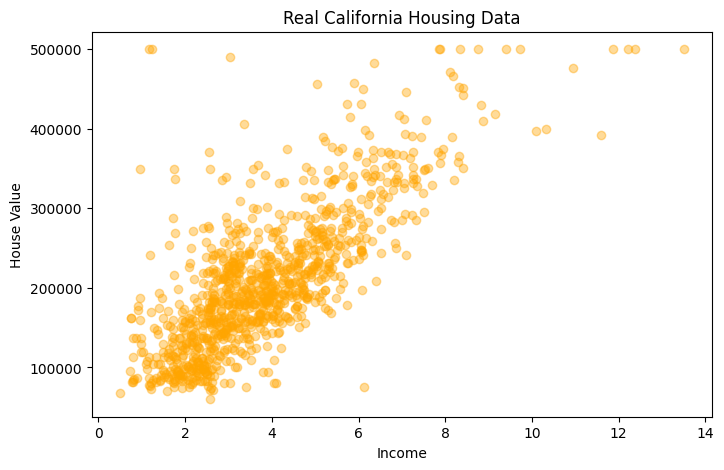

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the data you just uploaded
# Note: Ensure the filename matches exactly what you uploaded (usually 'housing.csv')
df = pd.read_csv('housing.csv')

# 2. Select our features
# We will use 'median_income' to predict 'median_house_value'
X = df['median_income'].values
y = df['median_house_value'].values

# 3. Handle missing values (Cleaning)
# Real datasets often have 'NaN' (Not a Number) values which break math
mask = ~np.isnan(X) & ~np.isnan(y)
X = X[mask]
y = y[mask]

print(f"Success! We have {len(X)} rows of real-world data.")

# Quick Check
plt.figure(figsize=(8, 5))
plt.scatter(X[:1000], y[:1000], alpha=0.4, color='orange')
plt.title("Real California Housing Data")
plt.xlabel("Income")
plt.ylabel("House Value")
plt.show()

In [ ]:
# Calculating Mean (average) and Standard Deviation (spread)
X_mean = np.mean(X)
X_std = np.std(X)

# Scaling X
X_scaled = (X - X_mean) / X_std

# We also scale y to keep the 'Loss' numbers small and manageable
y_mean = np.mean(y)
y_std = np.std(y)
y_scaled = (y - y_mean) / y_std

print("Data standardized! Everything is now centered around zero.")

Data standardized! Everything is now centered around zero.


In [ ]:
# --- THE BRAIN ---
# Hyperparameters (The settings we choose)
learning_rate = 0.1
epochs = 4000  # Number of times the brain looks at the whole dataset

# Parameters (The things the brain learns)
w = 0.0
b = 0.0

# To track progress
loss_history = []

n = len(X_scaled)

for i in range(epochs):
    # 1. Forward Pass: Make a prediction
    y_pred = (w * X_scaled) + b

    # 2. Calculate Loss (MSE)
    loss = (1/n) * np.sum((y_pred - y_scaled)**2)
    loss_history.append(loss)

    # 3. Backward Pass: Calculate the slopes (Gradients)
    dw = (2/n) * np.sum(X_scaled * (y_pred - y_scaled))
    db = (2/n) * np.sum(y_pred - y_scaled)

    # 4. Update: Adjust the weights
    w = w - (learning_rate * dw)
    b = b - (learning_rate * db)

    # Print progress every 200 steps
    if i % 200 == 0:
        print(f"Epoch {i}: Loss = {loss:.6f}, w = {w:.4f}, b = {b:.4f}")

print("Training Complete!")

Epoch 0: Loss = 1.000000, w = 0.1376, b = -0.0000
Epoch 200: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 400: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 600: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 800: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 1000: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 1200: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 1400: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 1600: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 1800: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 2000: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 2200: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 2400: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 2600: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 2800: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 3000: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 3200: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 3400: Loss = 0.526553, w = 0.6881, b = -0.0000
Epoch 3600: Loss = 0.526553, w = 0.6881, b = -0.0000


In [ ]:
# Predictions for the whole set
y_final_pred = (w * X_scaled) + b

# 1. Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_scaled - y_final_pred))

# 2. Mean Squared Error (MSE)
mse = np.mean((y_scaled - y_final_pred)**2)

# 3. R-Squared (R²)
ss_res = np.sum((y_scaled - y_final_pred)**2)
ss_tot = np.sum((y_scaled - np.mean(y_scaled))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"--- Custom Model Metrics ---")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

--- Custom Model Metrics ---
MAE: 0.5427
MSE: 0.5266
R2 Score: 0.4734


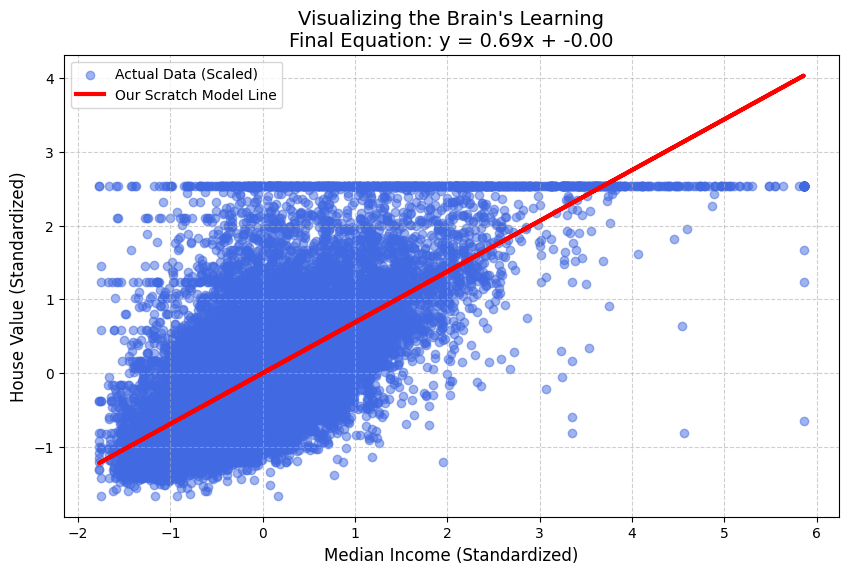

In [ ]:
# 1. Generate predictions for the visualization
# We use the final w and b our model learned
y_plot_pred = (w * X_scaled) + b

# 2. Create the plot
plt.figure(figsize=(10, 6))

# Plot the actual data points (using a small alpha to see density)
plt.scatter(X_scaled, y_scaled, color='royalblue', alpha=0.5, label='Actual Data (Scaled)')

# Plot our "From Scratch" line
# We use the min and max of X to draw a clean straight line
plt.plot(X_scaled, y_plot_pred, color='red', linewidth=3, label='Our Scratch Model Line')

# 3. Add labels and title
plt.title(f"Visualizing the Brain's Learning\nFinal Equation: y = {w:.2f}x + {b:.2f}", fontsize=14)
plt.xlabel("Median Income (Standardized)", fontsize=12)
plt.ylabel("House Value (Standardized)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()